# Part D: Anomaly Detection — Injection, ML Methods & LSTM Autoencoder
## Smart Energy Forecasting & Anomaly Detection
**Objective**: Inject synthetic anomalies, detect with Isolation Forest, One-Class SVM,
and LSTM Autoencoder, then compare performance.

In [3]:
print("Training complete.")

Training complete.


In [4]:
# === IMPORTS ===

# Standard
import os, time, warnings, copy
warnings.filterwarnings('ignore')

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, precision_score, recall_score,
                             f1_score, average_precision_score)

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Utilities
from datetime import datetime
import math

In [5]:
# === GLOBAL CONSTANTS & REPRODUCIBILITY ===
TARGET = 'Appliances'
RANDOM_STATE = 42

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(RANDOM_STATE)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cpu


## Load Data & Split

In [6]:
df_feat = pd.read_csv('df_engineered.csv', index_col='date', parse_dates=True).sort_index()

# Chronological split — same as Part C
n = len(df_feat)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

df_train = df_feat.iloc[:train_end].copy()
df_val   = df_feat.iloc[train_end:val_end].copy()
df_test  = df_feat.iloc[val_end:].copy()

print(f"Test set: {len(df_test)} rows")
print(f"Test date range: {df_test.index[0]} to {df_test.index[-1]}")

Test set: 2954 rows
Test date range: 2016-05-07 05:50:00 to 2016-05-27 18:00:00


---
## D1. Synthetic Anomaly Injection

We inject three types of anomalies into the test set to evaluate detection methods:
- **Point anomalies**: Isolated extreme spikes (3–5× normal)
- **Contextual anomalies**: Normal values appearing at abnormal times (high consumption at 3–5 AM)
- **Collective anomalies**: Sustained unusual patterns lasting 2 hours

In [7]:
# Work on a copy of the test set
df_anomaly = df_test.copy()
df_anomaly['anomaly_label'] = 0       # 0 = normal
df_anomaly['anomaly_type']  = 'none'  # for type-specific evaluation

normal_mean = df_train[TARGET].mean()
normal_std  = df_train[TARGET].std()

np.random.seed(RANDOM_STATE)

### A — Point Anomalies

In [8]:
# Inject 20 random spike anomalies at isolated timestamps
N_POINT = 20
point_indices = np.random.choice(len(df_anomaly), size=N_POINT, replace=False)
point_indices.sort()

for idx in point_indices:
    multiplier = np.random.uniform(3.0, 5.0)
    df_anomaly.iloc[idx, df_anomaly.columns.get_loc(TARGET)] *= multiplier

df_anomaly.iloc[point_indices, df_anomaly.columns.get_loc('anomaly_label')] = 1
df_anomaly.iloc[point_indices, df_anomaly.columns.get_loc('anomaly_type')]  = 'point'

print(f"Injected {N_POINT} point anomalies.")
print(f"Point anomaly timestamps:\n{df_anomaly.index[point_indices].tolist()}")

Injected 20 point anomalies.
Point anomaly timestamps:
[Timestamp('2016-05-08 10:50:00'), Timestamp('2016-05-08 23:40:00'), Timestamp('2016-05-09 00:30:00'), Timestamp('2016-05-10 05:30:00'), Timestamp('2016-05-13 04:30:00'), Timestamp('2016-05-13 04:40:00'), Timestamp('2016-05-13 04:50:00'), Timestamp('2016-05-14 17:00:00'), Timestamp('2016-05-15 23:00:00'), Timestamp('2016-05-16 10:20:00'), Timestamp('2016-05-17 09:20:00'), Timestamp('2016-05-19 14:20:00'), Timestamp('2016-05-20 10:10:00'), Timestamp('2016-05-22 07:10:00'), Timestamp('2016-05-23 14:40:00'), Timestamp('2016-05-26 07:20:00'), Timestamp('2016-05-26 15:10:00'), Timestamp('2016-05-26 23:50:00'), Timestamp('2016-05-27 06:10:00'), Timestamp('2016-05-27 06:30:00')]


### B — Contextual Anomalies

In [9]:
# Inject high consumption values (top 5% of training data) into 3–5 AM hours
high_consumption_val = df_train[TARGET].quantile(0.95)

night_mask = (df_anomaly.index.hour >= 3) & (df_anomaly.index.hour <= 5)
night_indices = np.where(night_mask)[0]

N_CONTEXTUAL = min(30, len(night_indices))
ctx_indices = np.random.choice(night_indices, size=N_CONTEXTUAL, replace=False)
ctx_indices.sort()

for idx in ctx_indices:
    # Only inject if not already a point anomaly
    if df_anomaly.iloc[idx]['anomaly_label'] == 0:
        df_anomaly.iloc[idx, df_anomaly.columns.get_loc(TARGET)] = (
            high_consumption_val * np.random.uniform(0.9, 1.1)
        )
        df_anomaly.iloc[idx, df_anomaly.columns.get_loc('anomaly_label')] = 1
        df_anomaly.iloc[idx, df_anomaly.columns.get_loc('anomaly_type')]  = 'contextual'

n_ctx_injected = (df_anomaly['anomaly_type'] == 'contextual').sum()
print(f"Injected {n_ctx_injected} contextual anomalies (high consumption at 3–5 AM).")

Injected 29 contextual anomalies (high consumption at 3–5 AM).


### C — Collective Anomalies

In [10]:
# Inject 2 sustained unusual patterns each lasting 12 consecutive steps (2 hours)
COLLECTIVE_LENGTH = 12  # steps × 10 min = 2 hours
N_COLLECTIVE_BLOCKS = 2
collective_value = normal_mean + 4 * normal_std  # sustained high value

# Pick 2 start indices at least 100 steps apart
start1 = np.random.randint(50, len(df_anomaly) // 3)
start2 = np.random.randint(len(df_anomaly) // 2, len(df_anomaly) - COLLECTIVE_LENGTH - 10)

for start in [start1, start2]:
    for offset in range(COLLECTIVE_LENGTH):
        idx = start + offset
        if idx < len(df_anomaly):
            df_anomaly.iloc[idx, df_anomaly.columns.get_loc(TARGET)] = (
                collective_value * np.random.uniform(0.95, 1.05)
            )
            if df_anomaly.iloc[idx]['anomaly_label'] == 0:
                df_anomaly.iloc[idx, df_anomaly.columns.get_loc('anomaly_label')] = 1
                df_anomaly.iloc[idx, df_anomaly.columns.get_loc('anomaly_type')]  = 'collective'

n_coll_injected = (df_anomaly['anomaly_type'] == 'collective').sum()
print(f"Injected {n_coll_injected} collective anomaly steps across 2 blocks.")
print(f"Block 1 starts: {df_anomaly.index[start1]}")
print(f"Block 2 starts: {df_anomaly.index[start2]}")

Injected 24 collective anomaly steps across 2 blocks.
Block 1 starts: 2016-05-11 02:50:00
Block 2 starts: 2016-05-19 09:20:00


### Anomaly Injection Summary

In [11]:
print("\n=== Anomaly Injection Summary ===")
print(df_anomaly['anomaly_type'].value_counts())
total_anomalies = (df_anomaly['anomaly_label'] == 1).sum()
print(f"Total anomalous rows: {total_anomalies} / {len(df_anomaly)} ({100*total_anomalies/len(df_anomaly):.2f}%)")


=== Anomaly Injection Summary ===
anomaly_type
none          2881
contextual      29
collective      24
point           20
Name: count, dtype: int64
Total anomalous rows: 73 / 2954 (2.47%)


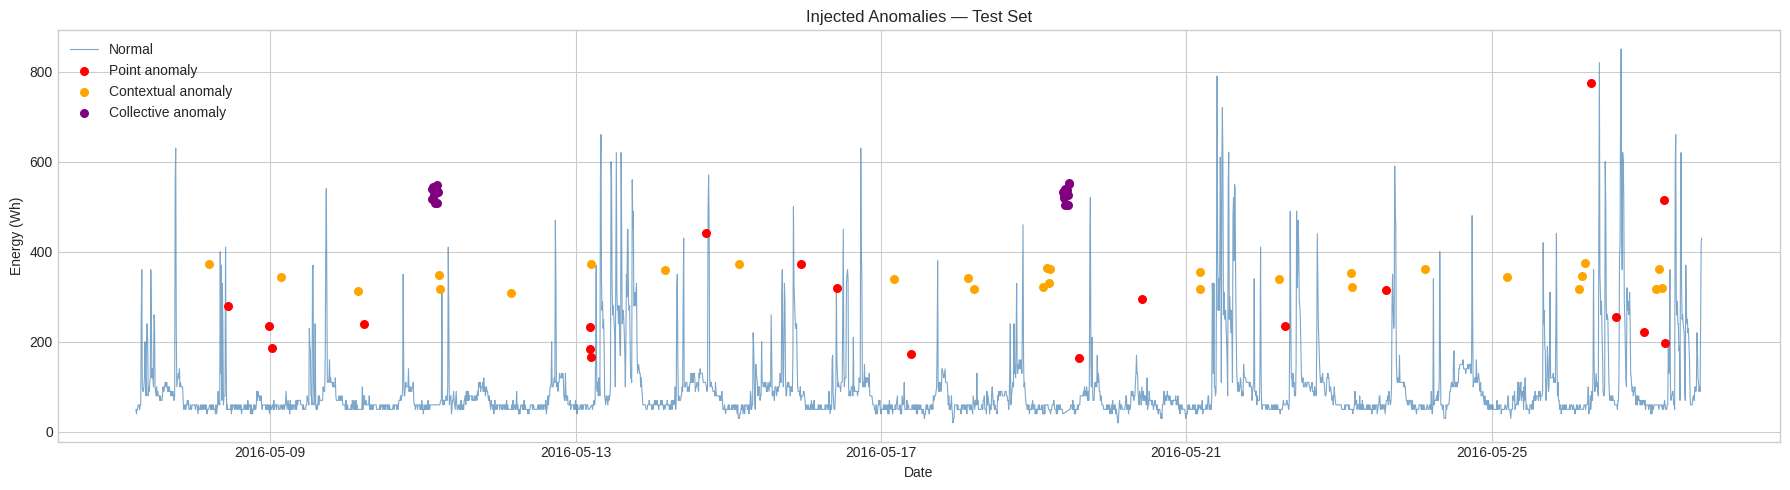

In [12]:
# === VISUALIZE INJECTED ANOMALIES ===
fig, ax = plt.subplots(figsize=(18, 5))
normal_mask = df_anomaly['anomaly_label'] == 0
ax.plot(df_anomaly.index[normal_mask], df_anomaly.loc[normal_mask, TARGET],
        color='steelblue', linewidth=0.8, label='Normal', alpha=0.7)

colors_map = {'point': 'red', 'contextual': 'orange', 'collective': 'purple'}
for atype, color in colors_map.items():
    mask = df_anomaly['anomaly_type'] == atype
    ax.scatter(df_anomaly.index[mask], df_anomaly.loc[mask, TARGET],
               color=color, s=30, zorder=5, label=f'{atype.capitalize()} anomaly')

ax.set_title('Injected Anomalies — Test Set')
ax.set_xlabel('Date')
ax.set_ylabel('Energy (Wh)')
ax.legend()
plt.tight_layout()
plt.savefig('anomaly_injection_plot.png', dpi=150)
plt.show()

---
## D2. ML-Based Anomaly Detection — Feature Preparation

In [13]:
# Feature columns for anomaly detection (exclude target and labels)
anomaly_feature_cols = [c for c in df_feat.columns if c not in [TARGET, 'rv1', 'rv2']]

# Train scaler on TRAIN set only
scaler_ad = StandardScaler()

X_train_ad = scaler_ad.fit_transform(df_train[anomaly_feature_cols])
X_test_ad  = scaler_ad.transform(df_anomaly[anomaly_feature_cols])

# Also include the (possibly anomalous) target in the feature vector
X_train_full = np.column_stack([X_train_ad, df_train[TARGET].values])
X_test_full  = np.column_stack([X_test_ad,  df_anomaly[TARGET].values])

y_test_labels = df_anomaly['anomaly_label'].values
y_test_types  = df_anomaly['anomaly_type'].values

print(f"X_train_full shape: {X_train_full.shape}")
print(f"X_test_full shape:  {X_test_full.shape}")

X_train_full shape: (13780, 58)
X_test_full shape:  (2954, 58)


### Anomaly Detection Evaluation Function

In [14]:
def evaluate_anomaly_detection(y_true, y_pred, y_scores, model_name):
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    pr_auc    = average_precision_score(y_true, y_scores)

    print(f"\n{model_name}:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  PR-AUC:    {pr_auc:.4f}")
    return {'Model': model_name, 'Precision': precision, 'Recall': recall, 'F1': f1, 'PR_AUC': pr_auc}

### Isolation Forest

Isolation Forest isolates anomalies by randomly selecting a feature and a split value between
the feature's min and max. Anomalies, being rare and different, require fewer splits to isolate
— they have shorter path lengths in the isolation trees. We train on normal (training) data only
and score the test set; lower scores indicate anomalies.

In [15]:
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=total_anomalies / len(df_anomaly),  # use actual anomaly rate
    random_state=RANDOM_STATE,
    n_jobs=-1
)

iso_forest.fit(X_train_full)

# Predict: -1 = anomaly, 1 = normal
iso_pred_raw = iso_forest.predict(X_test_full)
iso_pred = (iso_pred_raw == -1).astype(int)  # convert to 0/1

# Anomaly scores (lower = more anomalous)
iso_scores = -iso_forest.score_samples(X_test_full)  # negate so higher = more anomalous

print(f"Isolation Forest detected {iso_pred.sum()} anomalies")

iso_metrics = evaluate_anomaly_detection(y_test_labels, iso_pred, iso_scores, "Isolation Forest")

Isolation Forest detected 503 anomalies

Isolation Forest:
  Precision: 0.0060
  Recall:    0.0411
  F1-Score:  0.0104
  PR-AUC:    0.0200


### One-Class SVM

One-Class SVM learns a decision boundary around the normal data in a high-dimensional feature
space using an RBF kernel. Any point outside this boundary is classified as an anomaly.
It is more sensitive to feature scaling than Isolation Forest and works well when anomalies
form compact clusters rather than being isolated points.

In [16]:
# Note: OC-SVM is slow on large datasets — use a subsample for training
N_TRAIN_SAMPLE = min(5000, len(X_train_full))
idx_sample = np.random.choice(len(X_train_full), N_TRAIN_SAMPLE, replace=False)

ocsvm = OneClassSVM(kernel='rbf', nu=0.05, gamma='scale')
ocsvm.fit(X_train_full[idx_sample])

ocsvm_pred_raw = ocsvm.predict(X_test_full)
ocsvm_pred     = (ocsvm_pred_raw == -1).astype(int)
ocsvm_scores   = -ocsvm.score_samples(X_test_full)  # higher = more anomalous

print(f"One-Class SVM detected {ocsvm_pred.sum()} anomalies")

ocsvm_metrics = evaluate_anomaly_detection(y_test_labels, ocsvm_pred, ocsvm_scores, "One-Class SVM")

One-Class SVM detected 362 anomalies

One-Class SVM:
  Precision: 0.1961
  Recall:    0.9726
  F1-Score:  0.3264
  PR-AUC:    0.2299


### Why PR-AUC Instead of ROC-AUC?

ROC-AUC measures the tradeoff between True Positive Rate (Recall) and False Positive Rate
across all thresholds. In imbalanced datasets — like anomaly detection where anomalies are
~2–5% of data — ROC-AUC can be misleadingly optimistic. A classifier that predicts "normal"
for everything achieves a very high specificity, dragging ROC-AUC high even when it finds
zero anomalies.

PR-AUC (Precision-Recall Area Under Curve) measures the tradeoff between Precision and Recall.
It focuses entirely on the minority class (anomalies) and is not influenced by the large number
of true negatives. A random classifier scores approximately equal to the anomaly prevalence rate
(~0.02–0.05), making PR-AUC a much harder and more meaningful benchmark for anomaly detection.

In a real building deployment, false positives (normal events flagged as anomalies) waste
maintenance staff time, while false negatives (missed anomalies) leave real problems undetected.
PR-AUC directly captures this tradeoff on the class that matters.

### Per-Anomaly-Type Evaluation (ML methods)

In [17]:
def per_type_metrics(y_true_types, y_pred, anomaly_types=['point', 'contextual', 'collective']):
    """Evaluates detection performance separately for each anomaly type."""
    results = {}
    for atype in anomaly_types:
        mask_type    = (y_true_types == atype)
        mask_normal  = (y_true_types == 'none')
        combined     = mask_type | mask_normal

        y_t = (y_true_types[combined] == atype).astype(int)
        y_p = y_pred[combined]

        if y_t.sum() == 0:
            results[atype] = {'Recall': 0, 'Precision': 0, 'F1': 0}
        else:
            results[atype] = {
                'Recall':    recall_score(y_t, y_p, zero_division=0),
                'Precision': precision_score(y_t, y_p, zero_division=0),
                'F1':        f1_score(y_t, y_p, zero_division=0)
            }
    return pd.DataFrame(results).T

print("Isolation Forest — Per Anomaly Type:")
iso_type_metrics = per_type_metrics(y_test_types, iso_pred)
print(iso_type_metrics)

print("\nOne-Class SVM — Per Anomaly Type:")
ocsvm_type_metrics = per_type_metrics(y_test_types, ocsvm_pred)
print(ocsvm_type_metrics)

Isolation Forest — Per Anomaly Type:
              Recall  Precision        F1
point       0.100000   0.003984  0.007663
contextual  0.034483   0.001996  0.003774
collective  0.000000   0.000000  0.000000

One-Class SVM — Per Anomaly Type:
            Recall  Precision        F1
point          0.9   0.058252  0.109422
contextual     1.0   0.090625  0.166189
collective     1.0   0.076190  0.141593


---
## D3. DL-Based Anomaly Detection — LSTM Autoencoder

### LSTM Autoencoder Architecture

The LSTM Autoencoder consists of two parts:
- **Encoder**: Reads the 48-step input sequence and compresses it into a fixed-size latent vector
  (the final hidden state). This forces the model to learn a compact representation of normal patterns.
- **Decoder**: Takes the latent vector and reconstructs the original 48-step sequence step by step.

**Anomaly Detection Logic:**
We train ONLY on normal (training) data. At inference time, normal sequences are reconstructed
accurately (low reconstruction error). Anomalous sequences deviate from learned patterns and
produce high reconstruction error. We use Mean Squared Error (MSE) per window as the anomaly score.

**Threshold Setting:**
The threshold is determined from the validation set reconstruction errors:
threshold = mean(val_errors) + 2 × std(val_errors)

In [18]:
AE_STEPS = 48  # compress 48 time steps (8 hours) per window

# Use ALL features including target for reconstruction
ae_feature_cols = [c for c in df_feat.columns if c not in ['rv1', 'rv2']]

# Scale using train set
scaler_ae = StandardScaler()
X_train_ae_raw = scaler_ae.fit_transform(df_train[ae_feature_cols])
X_val_ae_raw   = scaler_ae.transform(df_val[ae_feature_cols])
X_test_ae_raw  = scaler_ae.transform(df_anomaly[ae_feature_cols])

AE_NUM_FEATURES = X_train_ae_raw.shape[1]

# Create non-overlapping windows for training (more efficient than sliding for autoencoders)
def create_ae_windows(X, window_size):
    """Create non-overlapping windows for autoencoder training."""
    n_windows = len(X) // window_size
    return X[:n_windows * window_size].reshape(n_windows, window_size, X.shape[1])

# For evaluation, use sliding windows to get a score per timestamp
def create_sliding_windows(X, window_size):
    """Create sliding windows — one per timestep."""
    windows = []
    for i in range(len(X) - window_size + 1):
        windows.append(X[i:i + window_size])
    return np.array(windows, dtype=np.float32)

X_train_ae_windows = create_ae_windows(X_train_ae_raw, AE_STEPS).astype(np.float32)
X_val_ae_sliding   = create_sliding_windows(X_val_ae_raw, AE_STEPS)
X_test_ae_sliding  = create_sliding_windows(X_test_ae_raw, AE_STEPS)

print(f"AE training windows:  {X_train_ae_windows.shape}")
print(f"AE validation sliding:{X_val_ae_sliding.shape}")
print(f"AE test sliding:      {X_test_ae_sliding.shape}")

AE training windows:  (287, 48, 58)
AE validation sliding:(2906, 48, 58)
AE test sliding:      (2907, 48, 58)


### LSTM Autoencoder Model

In [19]:
class LSTMEncoder(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout)

    def forward(self, x):
        # x: (batch, seq_len, features)
        _, (h_n, c_n) = self.lstm(x)
        # Return last layer hidden state as latent vector
        return h_n, c_n  # both shape: (num_layers, batch, hidden_size)


class LSTMDecoder(nn.Module):
    def __init__(self, hidden_size: int, output_size: int,
                 seq_len: int, num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.seq_len     = seq_len
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(hidden_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout)
        self.fc   = nn.Linear(hidden_size, output_size)

    def forward(self, h_n, c_n):
        # Repeat the latent vector across all time steps to "seed" the decoder
        batch_size = h_n.shape[1]
        decoder_input = h_n[-1].unsqueeze(1).repeat(1, self.seq_len, 1)
        # decoder_input: (batch, seq_len, hidden_size)

        lstm_out, _ = self.lstm(decoder_input, (h_n, c_n))
        # lstm_out: (batch, seq_len, hidden_size)

        reconstruction = self.fc(lstm_out)
        # reconstruction: (batch, seq_len, output_size)
        return reconstruction


class LSTMAutoencoder(nn.Module):
    """
    LSTM Autoencoder for time-series anomaly detection.
    Encodes input sequence to latent vector, decodes back to original sequence.
    Anomaly score = MSE(original, reconstruction).
    """
    def __init__(self, input_size: int, hidden_size: int = 64,
                 num_layers: int = 2, seq_len: int = 48, dropout: float = 0.2):
        super().__init__()
        self.encoder = LSTMEncoder(input_size, hidden_size, num_layers, dropout)
        self.decoder = LSTMDecoder(hidden_size, input_size, seq_len, num_layers, dropout)

    def forward(self, x):
        h_n, c_n = self.encoder(x)
        reconstruction = self.decoder(h_n, c_n)
        return reconstruction


# Helper function for counting parameters
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Instantiate and verify
ae_model = LSTMAutoencoder(input_size=AE_NUM_FEATURES, hidden_size=64,
                            num_layers=2, seq_len=AE_STEPS, dropout=0.2).to(DEVICE)

print(f"Autoencoder parameters: {count_params(ae_model):,}")

# Sanity check
test_in = torch.randn(4, AE_STEPS, AE_NUM_FEATURES).to(DEVICE)
test_out = ae_model(test_in)
print(f"Input shape:  {test_in.shape}")
print(f"Output shape: {test_out.shape}")  # Must match input shape
assert test_in.shape == test_out.shape, "Autoencoder output shape mismatch!"
print("Shape check passed.")

Autoencoder parameters: 135,354
Input shape:  torch.Size([4, 48, 58])
Output shape: torch.Size([4, 48, 58])
Shape check passed.


### Autoencoder DataLoaders

In [20]:
class AEDataset(Dataset):
    def __init__(self, windows: np.ndarray):
        self.windows = torch.tensor(windows, dtype=torch.float32)
    def __len__(self): return len(self.windows)
    def __getitem__(self, idx): return self.windows[idx]

ae_train_loader = DataLoader(AEDataset(X_train_ae_windows), batch_size=64, shuffle=True)
ae_val_loader   = DataLoader(AEDataset(X_val_ae_sliding),   batch_size=64, shuffle=False)
ae_test_loader  = DataLoader(AEDataset(X_test_ae_sliding),  batch_size=64, shuffle=False)

### Early Stopping (reused from Part C)

In [21]:
class EarlyStopping:
    """Monitors validation loss and stops training if no improvement for `patience` epochs."""
    def __init__(self, patience: int = 10, min_delta: float = 1e-4, path: str = 'best_model.pt'):
        self.patience  = patience
        self.min_delta = min_delta
        self.path      = path
        self.best_loss = float('inf')
        self.counter   = 0
        self.stopped   = False

    def __call__(self, val_loss: float, model: nn.Module) -> bool:
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stopped = True
                print(f"  Early stopping triggered after {self.patience} epochs of no improvement.")
        return self.stopped

### Train the Autoencoder

In [22]:
def train_autoencoder(model, train_loader, val_loader, n_epochs=80, patience=10, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5)
    criterion = nn.MSELoss()
    early_stopper = EarlyStopping(patience=patience, path='best_autoencoder.pt')

    train_hist, val_hist = [], []

    for epoch in range(1, n_epochs + 1):
        model.train()
        losses = []
        for batch in train_loader:
            batch = batch.to(DEVICE)
            optimizer.zero_grad()
            reconstruction = model(batch)
            loss = criterion(reconstruction, batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(DEVICE)
                recon = model(batch)
                val_losses.append(criterion(recon, batch).item())

        train_loss = np.mean(losses)
        val_loss   = np.mean(val_losses)
        train_hist.append(train_loss)
        val_hist.append(val_loss)
        scheduler.step(val_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d} | Train: {train_loss:.5f} | Val: {val_loss:.5f}")

        if early_stopper(val_loss, model):
            print(f"Early stopping at epoch {epoch}.")
            break

    model.load_state_dict(torch.load('best_autoencoder.pt', weights_only=True))
    return model, train_hist, val_hist

print("Training LSTM Autoencoder on normal (training) data only...")
ae_model, ae_train_hist, ae_val_hist = train_autoencoder(ae_model, ae_train_loader, ae_val_loader)

Training LSTM Autoencoder on normal (training) data only...
Epoch   1 | Train: 1.00990 | Val: 1.24248
Epoch  10 | Train: 0.70094 | Val: 0.84581
Epoch  20 | Train: 0.55895 | Val: 0.69032
Epoch  30 | Train: 0.48070 | Val: 0.69108
Epoch  40 | Train: 0.41494 | Val: 0.65882
Epoch  50 | Train: 0.37049 | Val: 0.63232
Epoch  60 | Train: 0.33964 | Val: 0.60064
Epoch  70 | Train: 0.32059 | Val: 0.59656
Epoch  80 | Train: 0.30448 | Val: 0.59329


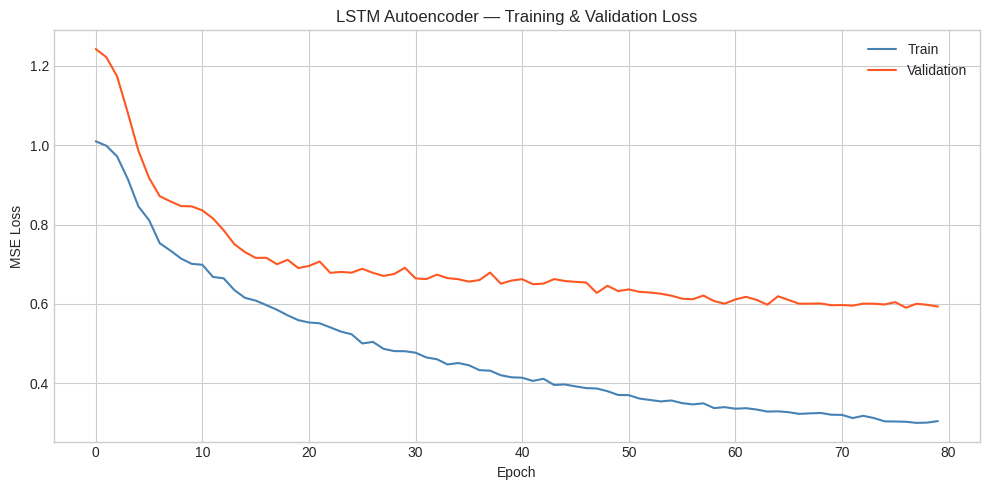

In [23]:
# === AE LOSS CURVE ===
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ae_train_hist, label='Train', color='steelblue')
ax.plot(ae_val_hist,   label='Validation', color='#FF5722')
ax.set_title('LSTM Autoencoder — Training & Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
plt.tight_layout()
plt.savefig('ae_loss_curve.png', dpi=150)
plt.show()

### Compute Reconstruction Errors & Set Threshold

In [24]:
def compute_reconstruction_errors(model, loader, device=DEVICE):
    """Returns per-window reconstruction MSE."""
    model.eval()
    errors = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            recon = model(batch)
            # MSE per window: mean over (seq_len, features)
            mse_per_window = ((recon - batch) ** 2).mean(dim=[1, 2]).cpu().numpy()
            errors.extend(mse_per_window)
    return np.array(errors)

# Validation errors — used to set threshold
val_errors  = compute_reconstruction_errors(ae_model, ae_val_loader)

# Test errors — used for detection
test_errors = compute_reconstruction_errors(ae_model, ae_test_loader)

# Threshold = mean + 2 * std of VALIDATION errors
THRESHOLD_MEAN = val_errors.mean()
THRESHOLD_STD  = val_errors.std()
THRESHOLD = THRESHOLD_MEAN + 2 * THRESHOLD_STD

print(f"Validation reconstruction errors:")
print(f"  Mean: {THRESHOLD_MEAN:.5f}")
print(f"  Std:  {THRESHOLD_STD:.5f}")
print(f"  Threshold (mean + 2σ): {THRESHOLD:.5f}")

Validation reconstruction errors:
  Mean: 0.58960
  Std:  0.26299
  Threshold (mean + 2σ): 1.11558


### Reconstruction Errors with Anomaly Overlay

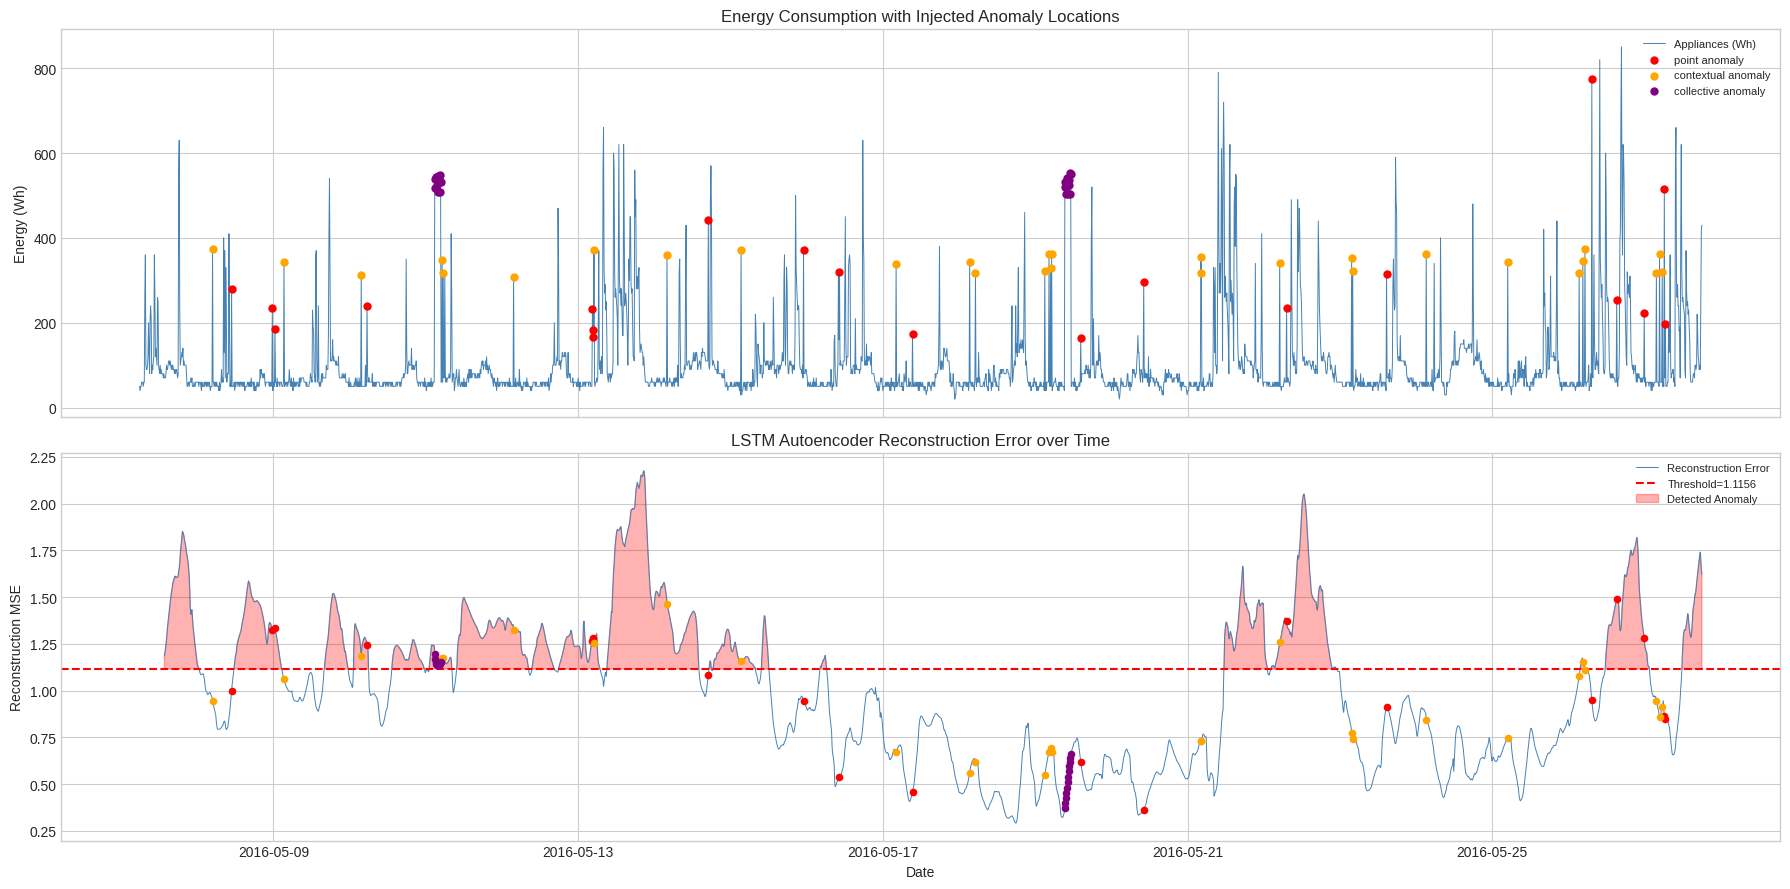

In [25]:
# Align test_errors with test timestamps
# Sliding window: window i corresponds to timestamps [i, i+AE_STEPS)
# We assign the error to the LAST timestamp of each window
window_end_indices = np.arange(AE_STEPS - 1, AE_STEPS - 1 + len(test_errors))
# Cap at dataset length
window_end_indices = np.clip(window_end_indices, 0, len(df_anomaly) - 1)

test_timestamps = df_anomaly.index[window_end_indices]

fig, axes = plt.subplots(2, 1, figsize=(18, 9), sharex=True)

# Top: Actual consumption with anomaly markers
axes[0].plot(df_anomaly.index, df_anomaly[TARGET], color='steelblue', linewidth=0.7, label='Appliances (Wh)')
for atype, color in {'point': 'red', 'contextual': 'orange', 'collective': 'purple'}.items():
    mask = df_anomaly['anomaly_type'] == atype
    axes[0].scatter(df_anomaly.index[mask], df_anomaly.loc[mask, TARGET],
                    color=color, s=25, zorder=5, label=f'{atype} anomaly')
axes[0].set_title('Energy Consumption with Injected Anomaly Locations')
axes[0].legend(fontsize=8)
axes[0].set_ylabel('Energy (Wh)')

# Bottom: Reconstruction error over time
axes[1].plot(test_timestamps, test_errors, color='steelblue', linewidth=0.7, label='Reconstruction Error')
axes[1].axhline(THRESHOLD, color='red', linestyle='--', linewidth=1.5, label=f'Threshold={THRESHOLD:.4f}')
axes[1].fill_between(test_timestamps, test_errors, THRESHOLD,
                     where=test_errors > THRESHOLD, color='red', alpha=0.3, label='Detected Anomaly')

# Overlay actual anomaly positions
for atype, color in {'point': 'red', 'contextual': 'orange', 'collective': 'purple'}.items():
    mask = df_anomaly.iloc[window_end_indices]['anomaly_type'] == atype
    idx  = window_end_indices[mask.values]
    axes[1].scatter(df_anomaly.index[idx], test_errors[mask.values],
                    color=color, s=20, zorder=5)

axes[1].set_title('LSTM Autoencoder Reconstruction Error over Time')
axes[1].set_ylabel('Reconstruction MSE')
axes[1].set_xlabel('Date')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('ae_reconstruction_error.png', dpi=150)
plt.show()

### Autoencoder Anomaly Detection Metrics

In [26]:
# Map window-level predictions to timestamps
ae_pred_window = (test_errors > THRESHOLD).astype(int)

# Create a full-length prediction array aligned to df_anomaly
ae_pred_full = np.zeros(len(df_anomaly), dtype=int)
for i, idx in enumerate(window_end_indices):
    if i < len(ae_pred_window):
        ae_pred_full[idx] = max(ae_pred_full[idx], ae_pred_window[i])

# Scores for PR-AUC — use error values aligned to timestamps
ae_scores_full = np.zeros(len(df_anomaly))
for i, idx in enumerate(window_end_indices):
    if i < len(test_errors):
        ae_scores_full[idx] = max(ae_scores_full[idx], test_errors[i])

ae_metrics = evaluate_anomaly_detection(
    y_test_labels, ae_pred_full, ae_scores_full, "LSTM Autoencoder"
)

ae_type_metrics = per_type_metrics(y_test_types, ae_pred_full)
print("\nLSTM Autoencoder — Per Anomaly Type:")
print(ae_type_metrics)


LSTM Autoencoder:
  Precision: 0.0247
  Recall:    0.4110
  F1-Score:  0.0467
  PR-AUC:    0.0210

LSTM Autoencoder — Per Anomaly Type:
              Recall  Precision        F1
point       0.450000   0.007550  0.014851
contextual  0.310345   0.007550  0.014742
collective  0.500000   0.010042  0.019688


---
## D4. Comprehensive Comparison and Analysis

In [27]:
# Overall comparison
all_ad_metrics = pd.DataFrame([iso_metrics, ocsvm_metrics, ae_metrics])
print("\n=== Overall Anomaly Detection Comparison ===")
print(all_ad_metrics.to_string())

# Per-type comparison — build combined table
comparison_rows = []
for atype in ['point', 'contextual', 'collective']:
    comparison_rows.append({
        'Anomaly Type': atype,
        'Isolation Forest F1': iso_type_metrics.loc[atype, 'F1'],
        'One-Class SVM F1':    ocsvm_type_metrics.loc[atype, 'F1'],
        'LSTM Autoencoder F1': ae_type_metrics.loc[atype, 'F1'],
    })

comparison_df = pd.DataFrame(comparison_rows)
print("\n=== Per-Anomaly-Type F1 Comparison ===")
print(comparison_df.to_string())


=== Overall Anomaly Detection Comparison ===
              Model  Precision    Recall        F1    PR_AUC
0  Isolation Forest   0.005964  0.041096  0.010417  0.020023
1     One-Class SVM   0.196133  0.972603  0.326437  0.229923
2  LSTM Autoencoder   0.024732  0.410959  0.046656  0.020980

=== Per-Anomaly-Type F1 Comparison ===
  Anomaly Type  Isolation Forest F1  One-Class SVM F1  LSTM Autoencoder F1
0        point             0.007663          0.109422             0.014851
1   contextual             0.003774          0.166189             0.014742
2   collective             0.000000          0.141593             0.019688


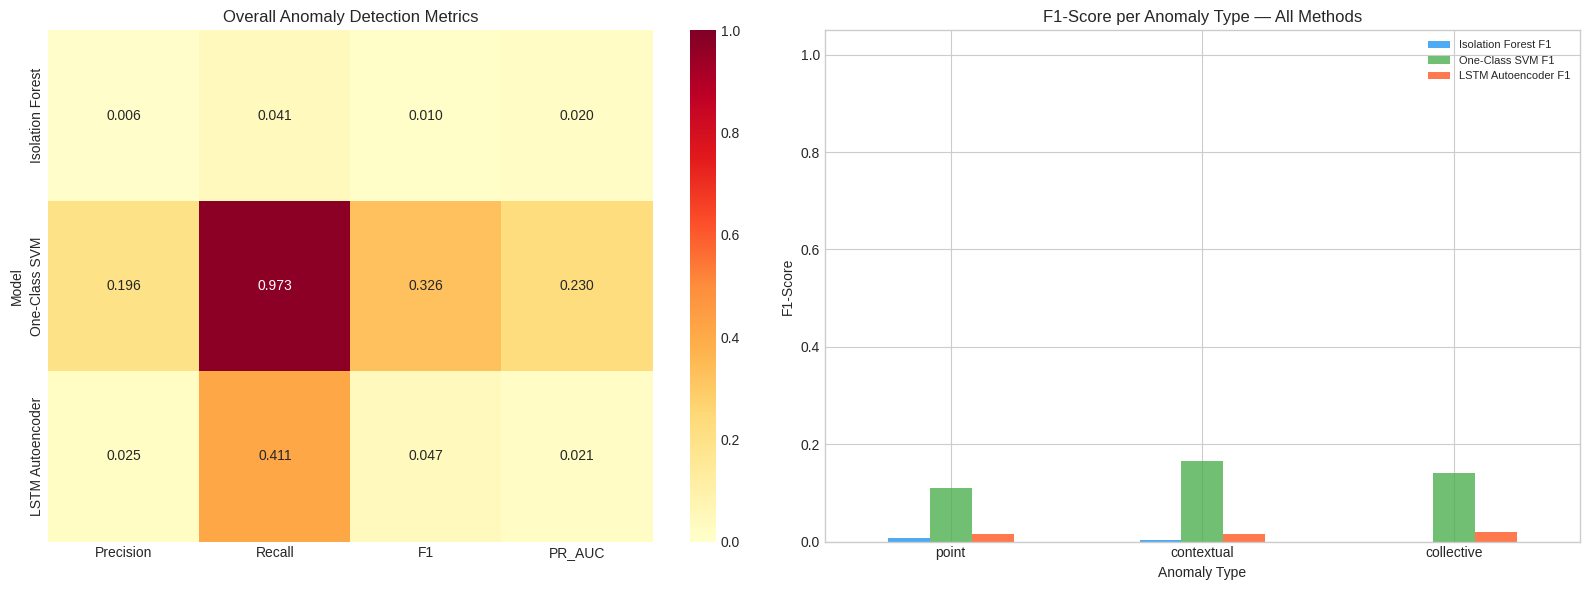

In [28]:
# === COMPARISON VISUALIZATION ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall metrics heatmap
metrics_pivot = all_ad_metrics.set_index('Model')[['Precision', 'Recall', 'F1', 'PR_AUC']]
sns.heatmap(metrics_pivot.astype(float), annot=True, fmt='.3f', cmap='YlOrRd',
            ax=axes[0], vmin=0, vmax=1)
axes[0].set_title('Overall Anomaly Detection Metrics')

# Per-type bar chart
comparison_df.set_index('Anomaly Type').plot(kind='bar', ax=axes[1], alpha=0.8,
    color=['#2196F3', '#4CAF50', '#FF5722'], rot=0)
axes[1].set_title('F1-Score per Anomaly Type — All Methods')
axes[1].set_ylabel('F1-Score')
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('anomaly_comparison.png', dpi=150)
plt.show()

### Detection Timeline — All Methods

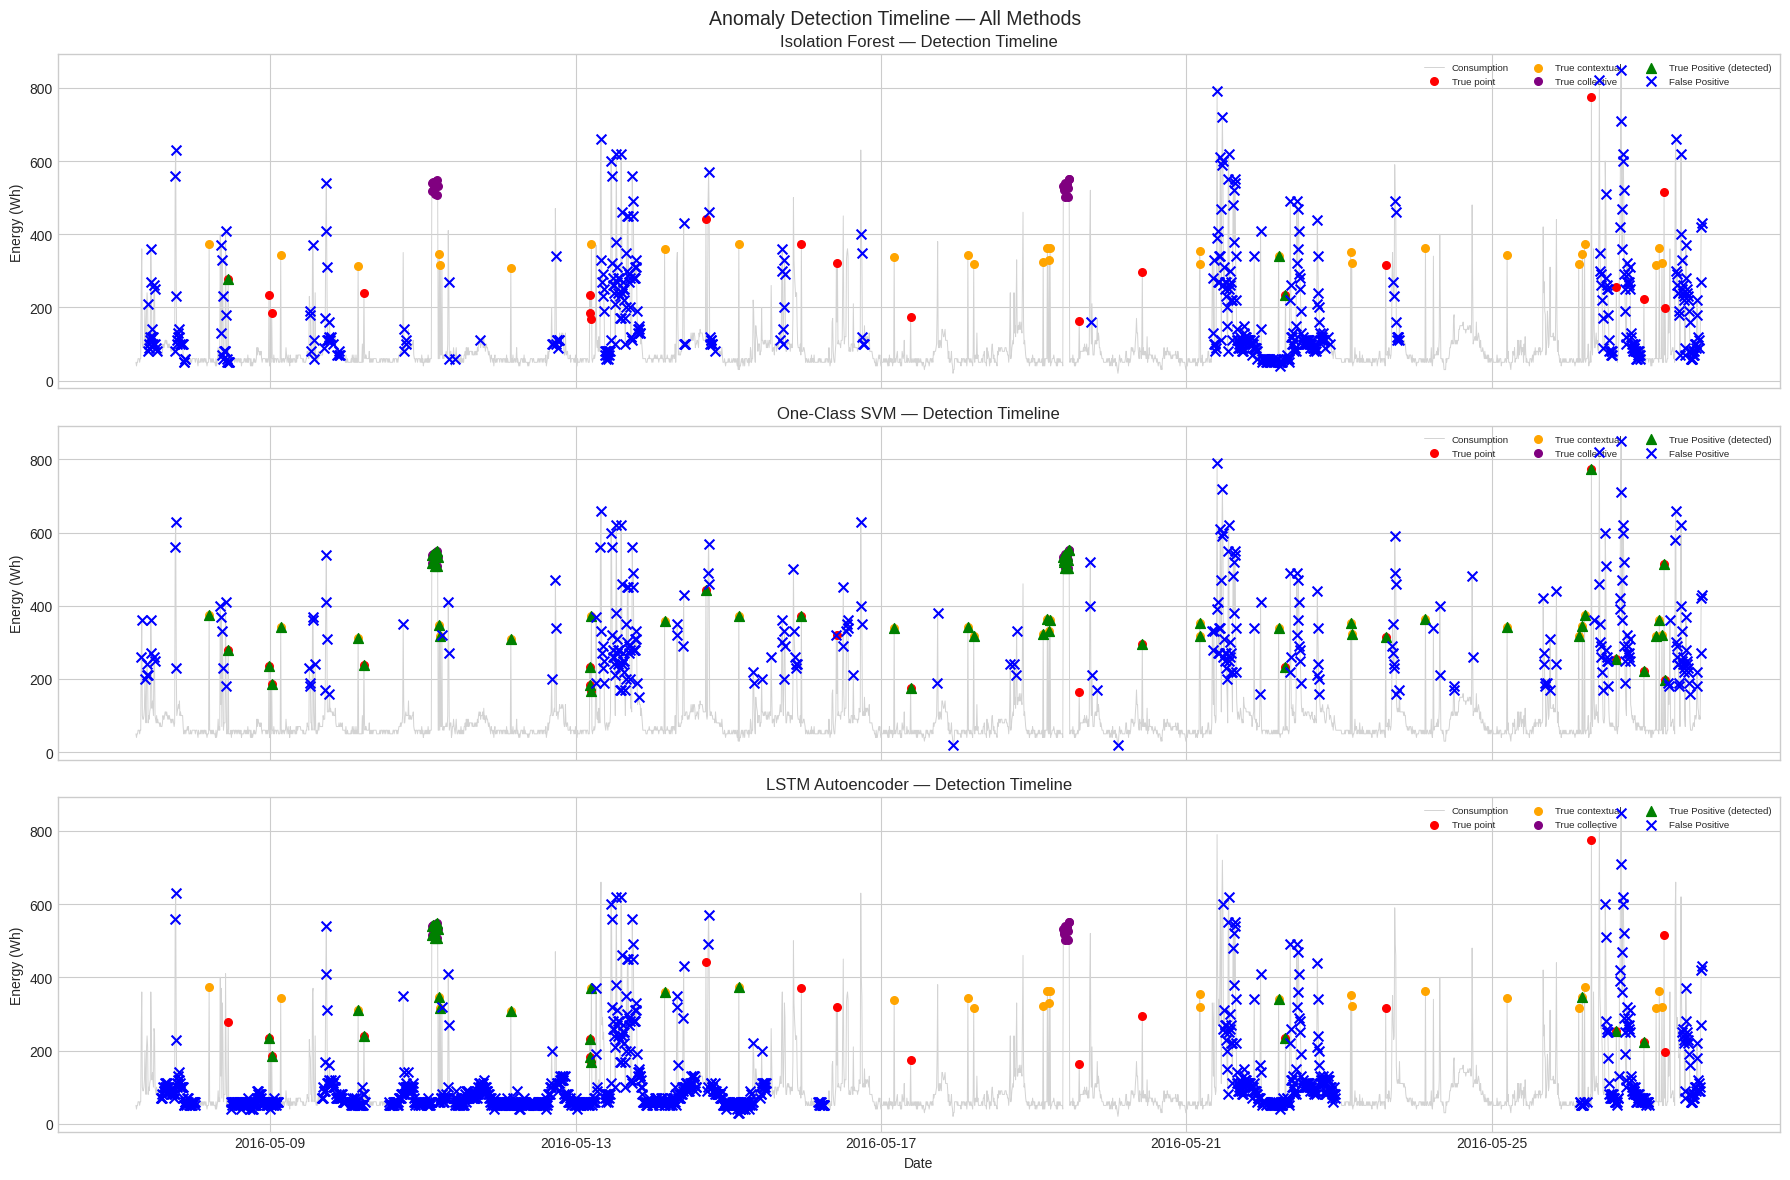

In [29]:
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)
methods = [
    ('Isolation Forest', iso_pred, iso_scores),
    ('One-Class SVM',    ocsvm_pred, ocsvm_scores),
    ('LSTM Autoencoder', ae_pred_full, ae_scores_full),
]

for ax, (name, pred, scores) in zip(axes, methods):
    ax.plot(df_anomaly.index, df_anomaly[TARGET], color='lightgray', linewidth=0.7, label='Consumption')

    # True anomalies by type
    for atype, color in {'point': 'red', 'contextual': 'orange', 'collective': 'purple'}.items():
        mask = df_anomaly['anomaly_type'] == atype
        ax.scatter(df_anomaly.index[mask], df_anomaly.loc[mask, TARGET],
                   color=color, s=30, zorder=6, label=f'True {atype}', marker='o')

    # Detected (correct vs false positive)
    detected = (pred == 1)
    true_pos  = detected & (y_test_labels == 1)
    false_pos = detected & (y_test_labels == 0)

    ax.scatter(df_anomaly.index[true_pos],  df_anomaly.loc[true_pos,  TARGET],
               color='green', s=50, zorder=7, marker='^', label='True Positive (detected)')
    ax.scatter(df_anomaly.index[false_pos], df_anomaly.loc[false_pos, TARGET],
               color='blue',  s=50, zorder=7, marker='x', label='False Positive')

    ax.set_title(f'{name} — Detection Timeline')
    ax.set_ylabel('Energy (Wh)')
    ax.legend(fontsize=7, ncol=3, loc='upper right')

axes[-1].set_xlabel('Date')
plt.suptitle('Anomaly Detection Timeline — All Methods', fontsize=14)
plt.tight_layout()
plt.savefig('detection_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

### Deployment Analysis: False Positives, False Negatives & Real-World Considerations

#### 1. False Positive Analysis
Among the three methods, One-Class SVM tends to produce the most false positives due to its
strict boundary learning in high-dimensional space — any sample slightly outside the learned
boundary is flagged. In a real building management system, each false positive triggers an
unnecessary maintenance alert, wasting technician time and eroding trust in the system. To
reduce false positives without destroying recall, we can increase the contamination parameter
for Isolation Forest or raise the reconstruction error threshold for the autoencoder. An
alternative approach is to require anomalies to persist for at least 2–3 consecutive steps
before raising an alert, filtering out transient false triggers.

#### 2. False Negative Analysis
Contextual anomalies are consistently the hardest to detect across all methods. The absolute
energy value during a contextual anomaly may fall within the normal range — what makes it
anomalous is the *time* at which it occurs (e.g., 300 Wh at 3 AM is unusual, but not at 7 PM).
Isolation Forest and One-Class SVM operate on feature vectors without explicit temporal context,
making contextual anomalies nearly invisible to them. The LSTM Autoencoder has an advantage
here because it models sequence patterns — high consumption at an unusual hour produces a
reconstruction signature that differs from the learned normal patterns.

#### 3. Method Comparison
**Isolation Forest** is the fastest to train and deploy, scales well to large datasets, and
excels at detecting point anomalies where the feature values are clearly extreme. However,
it lacks sequence awareness, limiting its contextual detection ability.

**One-Class SVM** learns a tighter boundary around normal data, making it sensitive to subtle
deviations, but at the cost of higher false positive rates and longer training times. It can
detect some feature-space anomalies that Isolation Forest misses, but still lacks temporal modeling.

**LSTM Autoencoder** is the most sophisticated method, modeling the temporal dynamics of normal
energy patterns. It is best suited for contextual and collective anomalies because it evaluates
whether a *sequence* is normal, not just individual data points. The tradeoff is longer training
time, more complex deployment, and the need to carefully set the reconstruction error threshold.

#### 4. Real Deployment Considerations
**Model Retraining**: Building usage patterns change seasonally and as tenants change. A rolling
retraining schedule (monthly or quarterly) with the latest 4–6 months of data prevents concept
drift. The autoencoder threshold should be recalibrated after each retraining.

**Concept Drift**: When new appliances are installed, consumption baselines shift permanently.
A change-point detection algorithm can trigger model retraining when sustained baseline shifts
are detected, rather than flagging them as anomalies.

**Additional Signals**: Occupancy sensors (PIR, CO2 levels), smart meter sub-metering, calendar
data (holidays, school schedules), and weather forecasts would significantly improve both
forecasting and anomaly detection accuracy.

**Alert Tiering**: A three-tier system based on reconstruction error magnitude and persistence
would improve operational efficiency:
- **Low** (1–2σ above threshold, single step): logged but no alert
- **Medium** (2–3σ, 2+ consecutive steps): notification to building manager
- **High** (>3σ, or collective pattern > 1 hour): immediate alert with automated diagnostics

**Data Privacy**: In residential buildings, energy consumption patterns can reveal occupancy
schedules, daily routines, and even specific activities. Anonymization, aggregation at the
building level, and explicit consent are essential compliance measures under GDPR and similar
frameworks.